In [1]:
import os
from utils import *

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

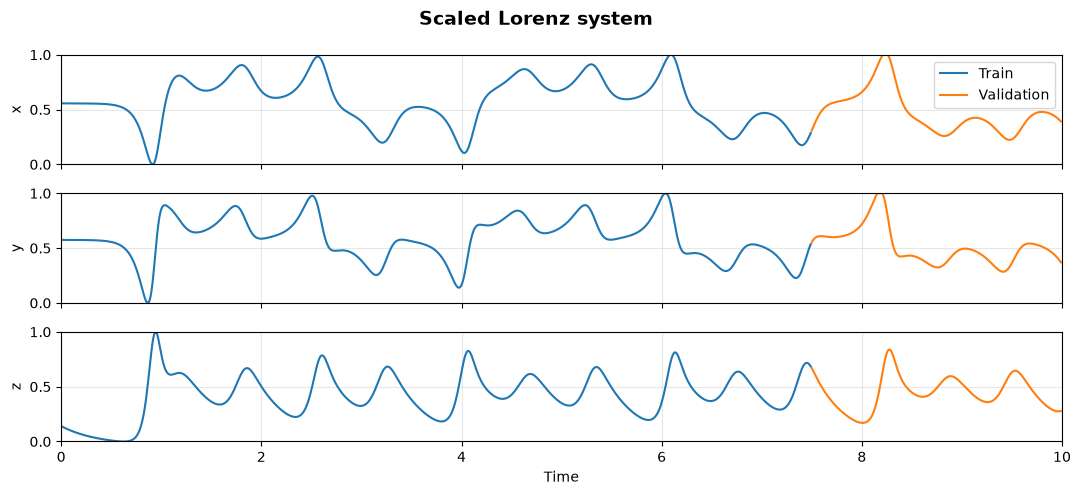

In [2]:
npoints = 1000
h = 0.01
params = [10, 28, 8 / 3]
init_point = [0, -0.01, 9]

dataset = generate_lorenz(
    npoints, 
    h,
    params, 
    init_point
)

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)
time = np.arange(npoints) * h

time_tr = time[:len(dataset_train)]
time_val = time[len(dataset_train):]

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = np.clip(val_scaled, 0, 1)

plot_lorenz(train_scaled, val_scaled, time_tr, time_val)

# Dense embedding

Instead of using standard $R_y$ encoding, in this section we employ a dense embedding, which allows all three channels to be embedded in one qubit:

$$
|X_{t,1},X_{t,2},X_{t,3}\rangle = R_z (\pi X_{t,3}) R_y (\pi X_{t,2}) R_z(\pi X_{t,1}) |+\rangle
$$

We consider two variants for the output stage:

- Using a single qubit and assigning each channel to the expectation value of one of the Pauli operators $[\langle X \rangle, \langle Y \rangle, \langle Z \rangle]$.
- Measuring the Pauli-Z operator on three different qubits, each corresponding to one channel.

In the first variant the outputs are very coupled since they come from the same qubit. The second variant overcomes this limitation with the cost of higher number of qubits needed.

In [3]:
# Params
batch_size = 128 
n_chanels = 3
window_size = 5
batch_size = 128
horizon = 1
nreps = 24
nqubits = window_size
weights = {"theta": (3 * nqubits * nreps,)} # Strongly entangling layers

# Training hyperparameters
epochs = 50
lr = 5e-4

In [4]:
# Create the sequences
x_tr, hor_tr = create_sequences(train_scaled, window_size, horizon)
x_val, hor_val = create_sequences(val_scaled, window_size, horizon)

x_tr = torch.from_numpy(x_tr).double()
hor_tr = torch.from_numpy(hor_tr).double()

x_val = torch.from_numpy(x_val).double()
hor_val = torch.from_numpy(hor_val).double()

tr_dataset = TensorDataset(x_tr, hor_tr)
tr_loader = DataLoader(tr_dataset, batch_size=batch_size, shuffle=False)

## Observables

In [5]:
# Create the PennyLane QNode
dev = qml.device("lightning.qubit", wires=nqubits)

def dense_vqc_obs(inputs, theta):
    dense_encoding(nqubits, inputs)
    VQC_strong(nqubits, theta, nreps)
    return qml.expval(qml.X(0)), qml.expval(qml.Y(0)), qml.expval(qml.Z(0))

dense_vqc_obs_node = qml.QNode(
    func=dense_vqc_obs,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)

class DenseVQCModelObs(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.qlayer = qml.qnn.TorchLayer(dense_vqc_obs_node, weights)

    def forward(self, x):
        x = x.reshape(x.shape[0], -1) # (batch, 15)
        x = self.qlayer(x) # (3, batch, 1)
        x = x.squeeze(-1) # (3, batch)
        x = x.T # (batch, 3)
        return (x + 1) / 2

In [ ]:
# reset_seeds(SEED)

# # Create the model
# model_DenseVQC_obs = DenseVQCModelObs()
# model_DenseVQC_obs.double()

# # Define optimizer and loss function
# opt_obs = torch.optim.Adam(params=model_DenseVQC_obs.parameters(), lr=lr)
# loss_fn = nn.MSELoss()

# # Save the best model
# best_state_obs = None
# best_val_loss_obs = float("inf")

# history_obs = {"Loss": [], "Val loss": []}

# print(30 * "#")
# print("Starting training")
# print(30 * "#")

# for epoch in range(epochs):

#     #Training
#     model_DenseVQC_obs.train()
#     epoch_loss = 0
#     for xb, yb in tr_loader:
#         opt_obs.zero_grad()
#         pred = model_DenseVQC_obs(xb)
#         target = yb.reshape(yb.shape[0], -1)
#         loss = loss_fn(pred, target)    
#         loss.backward()
#         opt_obs.step()
#         epoch_loss += loss.item()
    
#     # Store average loss for this epoch
#     epoch_loss /= len(tr_loader)
#     history_obs["Loss"].append(epoch_loss)

#     # Evaluation
#     model_DenseVQC_obs.eval()
#     with torch.no_grad():
#         val_pred = model_DenseVQC_obs(x_val)
#         val_target = hor_val.reshape(hor_val.shape[0], -1)
#         val_loss = loss_fn(val_pred, val_target).item()

#     # Store val loss
#     history_obs["Val loss"].append(val_loss)

#     # Save best model
#     if val_loss < best_val_loss_obs:
#         best_val_loss_obs = val_loss
#         best_state_obs = {
#             name: params.detach().clone()
#             for name, params in model_DenseVQC_obs.state_dict().items()
#         }

#     # Print training progress every 5 epochs
#     if epoch == 0 or (epoch + 1) % 5 == 0:
#         print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


# if best_state_obs is not None:
#     model_DenseVQC_obs.load_state_dict(best_state_obs)

##############################
Starting training
##############################
Epoch: 1 | Loss: 0.0349 | Validation loss: 0.0250
Epoch: 5 | Loss: 0.0272 | Validation loss: 0.0197
Epoch: 10 | Loss: 0.0226 | Validation loss: 0.0162
Epoch: 15 | Loss: 0.0200 | Validation loss: 0.0145
Epoch: 20 | Loss: 0.0184 | Validation loss: 0.0135
Epoch: 25 | Loss: 0.0172 | Validation loss: 0.0129
Epoch: 30 | Loss: 0.0163 | Validation loss: 0.0125
Epoch: 35 | Loss: 0.0156 | Validation loss: 0.0122
Epoch: 40 | Loss: 0.0151 | Validation loss: 0.0119
Epoch: 45 | Loss: 0.0146 | Validation loss: 0.0116
Epoch: 50 | Loss: 0.0142 | Validation loss: 0.0114


In [ ]:
# # Save the model
# os.makedirs("../models_states", exist_ok=True)

# checkpoint = {
#     "vqc_dense_obs": model_DenseVQC_obs.state_dict(),
#     "history": history_obs
# }
# torch.save(checkpoint, "../models_states/vqc_dense_obs.pt")

In [ ]:
# Load the model
checkpoint = torch.load(
    "../models_states/vqc_dense_obs.pt",
    map_location="cpu"
)

history_obs = checkpoint["history"]

model_DenseVQC_obs = DenseVQCModelObs().double()
model_DenseVQC_obs.load_state_dict(checkpoint["vqc_dense_obs"])

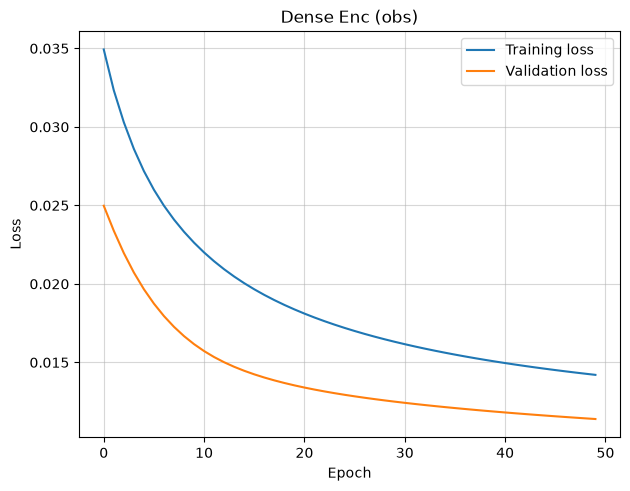

In [9]:
plot_loss(history_obs, "Dense Enc (obs)")

In [10]:
# Evaluation mode
model_DenseVQC_obs.eval()

with torch.no_grad():
    pred_obs = model_DenseVQC_obs(x_val)

pred_obs_3d = pred_obs.reshape(pred_obs.shape[0], 1, 3)
target_obs_3d = hor_val

# =====================
# RMSE
# =====================

squared_error = (pred_obs_3d - target_obs_3d) ** 2
mean_rmse_list_obs = torch.sqrt(squared_error.mean(dim=(1, 2)))
mean_rmse_obs = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred_obs_3d - target_obs_3d)
mean_mae_list_obs = abs_error.mean(dim=(1, 2))
mean_mae_obs = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target_obs_3d - pred_obs_3d) / (target_obs_3d + eps))
mean_mape_list_obs = percentage_error.mean(dim=(1, 2))
mean_mape_obs = percentage_error.mean()

print(f"Global RMSE observables measurement: {mean_rmse_obs:.4f}")
print(f"Global MAE obs observables measurement: {mean_mae_obs:.4f}")
print(f"Global MAPE obs observables measurement: {mean_mape_obs:.4f}")

Global RMSE observables measurement: 0.1067
Global MAE obs observables measurement: 0.0585
Global MAPE obs observables measurement: 0.1228


In [22]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "short-term",
        "model": "Dense Enc (obs)",
        "MAPE": mean_mape_obs,
        "MAE": mean_mae_obs,
        "RMSE": mean_rmse_obs,
    },
)

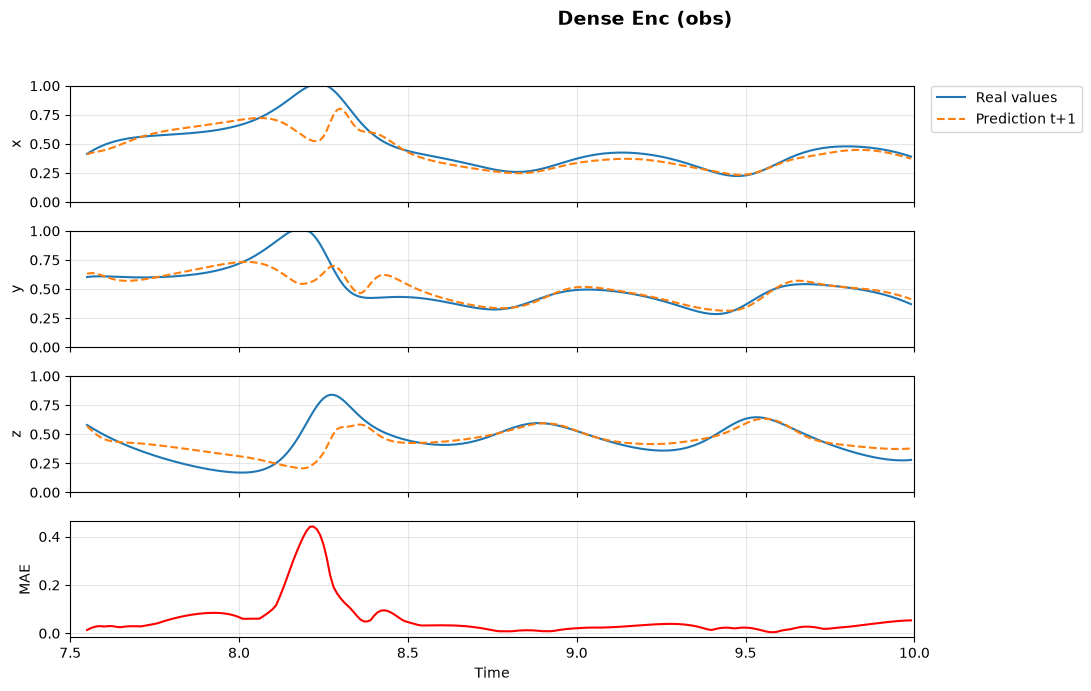

In [12]:
pred_x_obs = pred_obs_3d[:, :, 0]
pred_y_obs = pred_obs_3d[:, :, 1]
pred_z_obs = pred_obs_3d[:, :, 2]

plot_preds_and_error(
    pred_x_obs,
    pred_y_obs,
    pred_z_obs,
    mean_mae_list_obs,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    title="Dense Enc (obs)"
)

## Qubits

In [13]:
# Create the PennyLane QNode
dev = qml.device("lightning.qubit", wires=nqubits)

def dense_vqc_qu(inputs, theta):
    dense_encoding(nqubits, inputs)
    VQC_strong(nqubits, theta, nreps)
    return qml.expval(qml.Z(0)), qml.expval(qml.Z(1)), qml.expval(qml.Z(2))

dense_vqc_qu_node = qml.QNode(
    func=dense_vqc_qu,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)

class DenseVQCModelQubit(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.qlayer = qml.qnn.TorchLayer(dense_vqc_qu_node, weights)

    def forward(self, x):
        x = x.reshape(x.shape[0], -1) # (batch, 15)
        x = self.qlayer(x) # (3, batch, 1)
        x = x.squeeze(-1) # (3, batch)
        x = x.T # (batch, 3)
        return (x + 1) / 2

In [ ]:
# reset_seeds(SEED)

# # Create the model
# model_DenseVQC_qu = DenseVQCModelQubit()
# model_DenseVQC_qu.double()

# # Define optimizer and loss function
# opt_qu = torch.optim.Adam(params=model_DenseVQC_qu.parameters(), lr=lr)
# loss_fn = nn.MSELoss()

# # Save the best model
# best_state_qu = None
# best_val_loss_qu = float("inf")

# history_qu = {"Loss": [], "Val loss": []}

# print(30 * "#")
# print("Starting training")
# print(30 * "#")

# for epoch in range(epochs):

#     #Training
#     model_DenseVQC_qu.train()
#     epoch_loss = 0
#     for xb, yb in tr_loader:
#         opt_qu.zero_grad()
#         pred = model_DenseVQC_qu(xb)
#         target = yb.reshape(yb.shape[0], -1)
#         loss = loss_fn(pred, target)    
#         loss.backward()
#         opt_qu.step()
#         epoch_loss += loss.item()
    
#     # Store average loss for this epoch
#     epoch_loss /= len(tr_loader)
#     history_qu["Loss"].append(epoch_loss)

#     # Evaluation
#     model_DenseVQC_qu.eval()
#     with torch.no_grad():
#         val_pred = model_DenseVQC_qu(x_val)
#         val_target = hor_val.reshape(hor_val.shape[0], -1)
#         val_loss = loss_fn(val_pred, val_target).item()

#     # Store val loss
#     history_qu["Val loss"].append(val_loss)

#     # Save best model
#     if val_loss < best_val_loss_qu:
#         best_val_loss_qu = val_loss
#         best_state_qu = {
#             name: params.detach().clone()
#             for name, params in model_DenseVQC_qu.state_dict().items()
#         }

#     # Print training progress every 5 epochs
#     if epoch == 0 or (epoch + 1) % 5 == 0:
#         print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


# if best_state_qu is not None:
#     model_DenseVQC_qu.load_state_dict(best_state_qu)

##############################
Starting training
##############################
Epoch: 1 | Loss: 0.0511 | Validation loss: 0.0374
Epoch: 5 | Loss: 0.0415 | Validation loss: 0.0310
Epoch: 10 | Loss: 0.0326 | Validation loss: 0.0240
Epoch: 15 | Loss: 0.0262 | Validation loss: 0.0188
Epoch: 20 | Loss: 0.0219 | Validation loss: 0.0156
Epoch: 25 | Loss: 0.0191 | Validation loss: 0.0138
Epoch: 30 | Loss: 0.0174 | Validation loss: 0.0128
Epoch: 35 | Loss: 0.0163 | Validation loss: 0.0122
Epoch: 40 | Loss: 0.0155 | Validation loss: 0.0119
Epoch: 45 | Loss: 0.0149 | Validation loss: 0.0116
Epoch: 50 | Loss: 0.0144 | Validation loss: 0.0114


In [ ]:
# # Save the model
# os.makedirs("../models_states", exist_ok=True)

# checkpoint = {
#     "vqc_dense_qu": model_DenseVQC_qu.state_dict(),
#     "history": history_qu
# }
# torch.save(checkpoint, "../models_states/vqc_dense_qu.pt")

In [ ]:
# Load the model
checkpoint = torch.load(
    "../models_states/vqc_dense_qu.pt",
    map_location="cpu"
)

history_qu = checkpoint["history"]

model_DenseVQC_qu = DenseVQCModelQubit().double()
model_DenseVQC_qu.load_state_dict(checkpoint["vqc_dense_qu"])

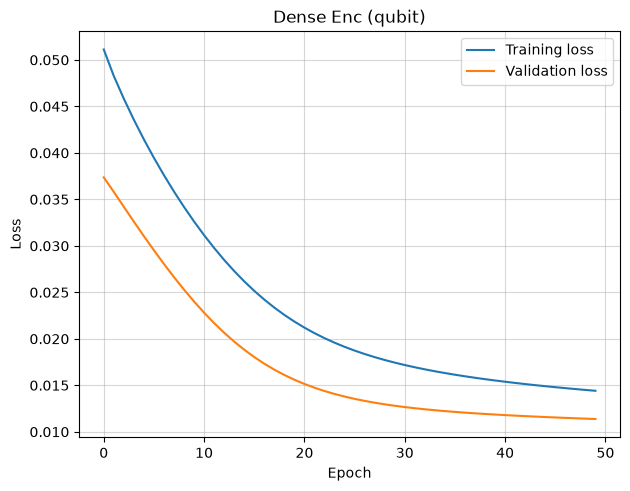

In [17]:
plot_loss(history_qu, "Dense Enc (qubit)")

In [18]:
# Evaluation mode
model_DenseVQC_qu.eval()

with torch.no_grad():
    pred_qu = model_DenseVQC_qu(x_val)

pred_qu_3d = pred_qu.reshape(pred_qu.shape[0], 1, 3)
target_qu_3d = hor_val

# =====================
# RMSE
# =====================

squared_error = (pred_qu_3d - target_qu_3d) ** 2
mean_rmse_list_qu = torch.sqrt(squared_error.mean(dim=(1, 2)))
mean_rmse_qu = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred_qu_3d - target_qu_3d)
mean_mae_list_qu = abs_error.mean(dim=(1, 2))
mean_mae_qu = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target_qu_3d - pred_qu_3d) / (target_qu_3d + eps))
mean_mape_list_qu = percentage_error.mean(dim=(1, 2))
mean_mape_qu = percentage_error.mean()

print(f"Global RMSE qubit measurement: {mean_rmse_qu:.4f}")
print(f"Global MAE qubit measurement: {mean_mae_qu:.4f}")
print(f"Global MAPE qubit measurement: {mean_mape_qu:.4f}")

Global RMSE qubit measurement: 0.1066
Global MAE qubit measurement: 0.0626
Global MAPE qubit measurement: 0.1292


In [19]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "short-term",
        "model": "Dense Enc (qubits)",
        "MAPE": mean_mape_qu,
        "MAE": mean_mae_qu,
        "RMSE": mean_rmse_qu,
    },
)

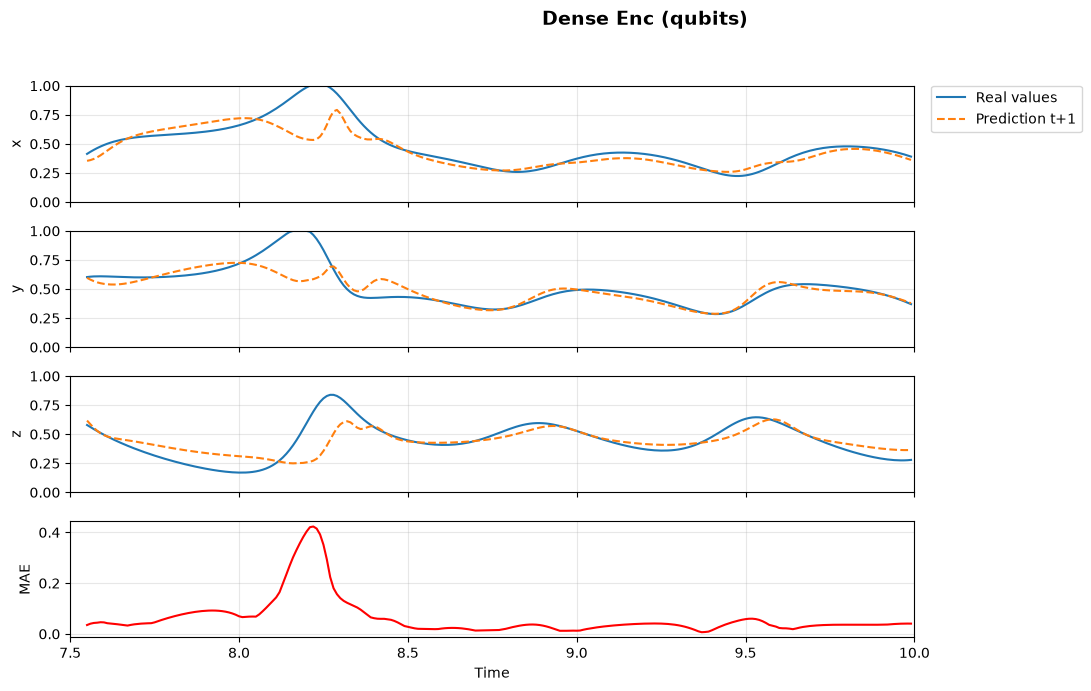

In [20]:
pred_x_qu = pred_qu_3d[:, :, 0]
pred_y_qu = pred_qu_3d[:, :, 1]
pred_z_qu = pred_qu_3d[:, :, 2]

plot_preds_and_error(
    pred_x_qu,
    pred_y_qu,
    pred_z_qu,
    mean_mae_list_qu,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    title="Dense Enc (qubits)"
)